逻辑回归线性表达式：
z = 1.2 * x + (-0.5)

sigmoid 函数：
P(y=1) = 1 / (1 + e^(-z))

分类规则：
P(y=1) >= 0.5 -> 分类为 1
P(y=1) <  0.5 -> 分类为 0

样本计算结果：
x	z		P(y=1)		分类
-4	-5.3000		 0.0050		0
-2	-2.9000		 0.0522		0
-1	-1.7000		 0.1545		0
 0	-0.5000		 0.3775		0
 1	 0.7000		 0.6682		1
 2	 1.9000		 0.8699		1
 3	 3.1000		 0.9569		1
 4	 4.3000		 0.9866		1


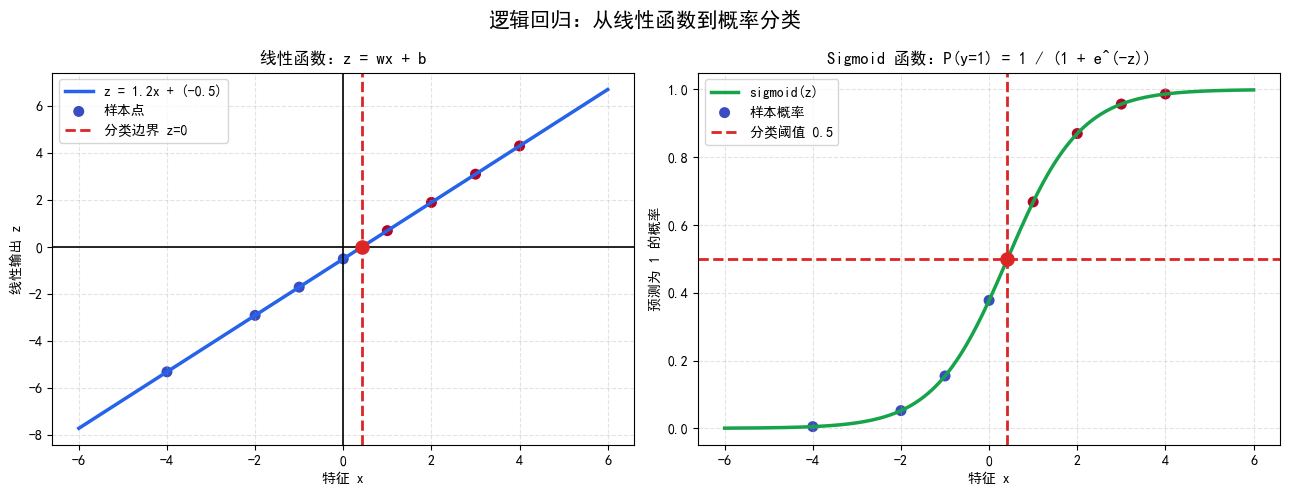

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rcParams


# 配置中文字体，避免图表中文乱码。
rcParams["font.family"] = ["SimHei", "Microsoft YaHei"]
plt.rcParams["axes.unicode_minus"] = False


# 1. 模拟一个只包含一个特征的数据集。
# x 可以理解为“每天学习小时数”。
x_data = np.array([-4, -2, -1, 0, 1, 2, 3, 4])


# 2. 人为指定逻辑回归模型的线性部分。
# 逻辑回归不是直接用 z 做分类，而是先计算线性表达式：
# z = w * x + b
w = 1.2
b = -0.5
z_data = w * x_data + b


# 3. 使用 sigmoid 函数把 z 转成 0 到 1 之间的概率。
# 概率越接近 1，越倾向于分类为 1；概率越接近 0，越倾向于分类为 0。
y_probability = 1 / (1 + np.exp(-z_data))


# 4. 根据概率做分类。
# 这里使用常见阈值 0.5：
# P >= 0.5 分类为 1，否则分类为 0。
y_pred = (y_probability >= 0.5).astype(int)


print("逻辑回归线性表达式：")
print(f"z = {w} * x + ({b})")
print()
print("sigmoid 函数：")
print("P(y=1) = 1 / (1 + e^(-z))")
print()
print("分类规则：")
print("P(y=1) >= 0.5 -> 分类为 1")
print("P(y=1) <  0.5 -> 分类为 0")
print()
print("样本计算结果：")
print("x\tz\t\tP(y=1)\t\t分类")
for x, z, probability, pred in zip(x_data, z_data, y_probability, y_pred):
    print(f"{x:>2}\t{z:>7.4f}\t\t{probability:>7.4f}\t\t{pred}")


# 5. 为画图准备更密集的 x，用来画平滑曲线。
x_line = np.linspace(-6, 6, 300)
z_line = w * x_line + b
sigmoid_line = 1 / (1 + np.exp(-z_line))


# 当 z = 0 时，sigmoid(z) = 0.5，这是逻辑回归的分类边界。
# z = w*x + b = 0，所以 x = -b / w。
decision_x = -b / w


plt.figure(figsize=(13, 5))


# 左图：线性表达式 z = w*x + b
plt.subplot(1, 2, 1)
plt.plot(x_line, z_line, color="#2563eb", linewidth=2.5, label=f"z = {w}x + ({b})")
plt.scatter(x_data, z_data, c=y_pred, cmap="coolwarm", s=80, edgecolor="white", label="样本点")
plt.axhline(0, color="black", linewidth=1.2)
plt.axvline(0, color="black", linewidth=1.2)
plt.axvline(decision_x, color="#dc2626", linestyle="--", linewidth=2, label="分类边界 z=0")
plt.scatter([decision_x], [0], color="#dc2626", s=90, zorder=5)
plt.title("线性函数：z = wx + b")
plt.xlabel("特征 x")
plt.ylabel("线性输出 z")
plt.grid(True, linestyle="--", alpha=0.35)
plt.legend()


# 右图：sigmoid 函数，把 z 转换成概率
plt.subplot(1, 2, 2)
plt.plot(x_line, sigmoid_line, color="#16a34a", linewidth=2.5, label="sigmoid(z)")
plt.scatter(x_data, y_probability, c=y_pred, cmap="coolwarm", s=80, edgecolor="white", label="样本概率")
plt.axhline(0.5, color="#dc2626", linestyle="--", linewidth=2, label="分类阈值 0.5")
plt.axvline(decision_x, color="#dc2626", linestyle="--", linewidth=2)
plt.scatter([decision_x], [0.5], color="#dc2626", s=90, zorder=5)
plt.title("Sigmoid 函数：P(y=1) = 1 / (1 + e^(-z))")
plt.xlabel("特征 x")
plt.ylabel("预测为 1 的概率")
plt.ylim(-0.05, 1.05)
plt.grid(True, linestyle="--", alpha=0.35)
plt.legend()


plt.suptitle("逻辑回归：从线性函数到概率分类", fontsize=15)
plt.tight_layout()
plt.savefig("logistic_regression_formula_demo.png", dpi=160, bbox_inches="tight")
plt.show()